# Hang Seng Index Sentiment - Price Analysis

## Overview
This notebook analyses 747 trading days of HSI OHLC data paired with social-media sentiment votes (up-votes / down-votes collected before market open). The analysis covers:

1. Data loading and cleaning  
2. Exploratory data analysis (EDA)  
3. Sentiment-return correlation analysis  
4. Strategy design and back-testing  
5. Performance evaluation

## 1. Imports and Configuration

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Loading and Cleaning Data

In [30]:
df = pd.read_excel('HSI.xlsx')
df.head()
df['Date'] = pd.to_datetime(df['Date'])

# Daily Return, Range, Sentiment Score
df['Daily Return'] = df['Close'].pct_change()
df['Range'] = df['High'] - df['Low']
df['Sentiment'] = df['Up votes'] - df['Down votes']


In [31]:
print(f"Total rows: {len(df)}")
print(f"Rows with Sentiment data: {df['Sentiment'].notna().sum()}") # Sentiments columns has missing values

Total rows: 747
Rows with Sentiment data: 552


In [32]:
print("=== Price Statistics ===")
print(df[['Open','High','Low','Close']].describe().round(2))
print()
print("=== Sentiment Statistics ===")
print(df[['Up votes','Down votes','Sentiment']].describe().round(4))

=== Price Statistics ===
           Open      High       Low     Close
count    747.00    747.00    747.00    747.00
mean   19050.84  19228.44  18870.63  19049.84
std     1883.94   1903.57   1853.86   1888.09
min    14830.69  15113.15  14597.31  14687.02
25%    17574.21  17689.60  17400.99  17524.56
50%    19254.38  19378.90  19072.72  19229.97
75%    20359.60  20550.93  20141.36  20359.56
max    24182.02  24669.62  24065.01  24369.71

=== Sentiment Statistics ===
       Up votes  Down votes  Sentiment
count  552.0000    552.0000   552.0000
mean     0.5406      0.4597     0.0809
std      0.1020      0.1018     0.2036
min      0.2400      0.1800    -0.5200
25%      0.4700      0.3900    -0.0600
50%      0.5400      0.4600     0.0800
75%      0.6100      0.5300     0.2200
max      0.8200      0.7600     0.6400


## 3. Exploratory Data Analysis
### Price History

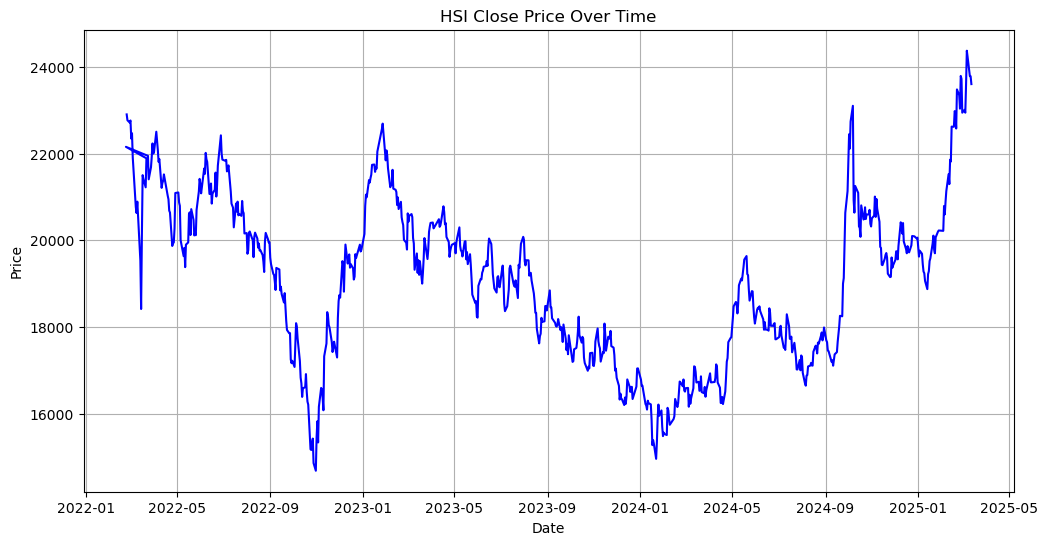

In [33]:
# Plot Price History
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
plt.title('HSI Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid()

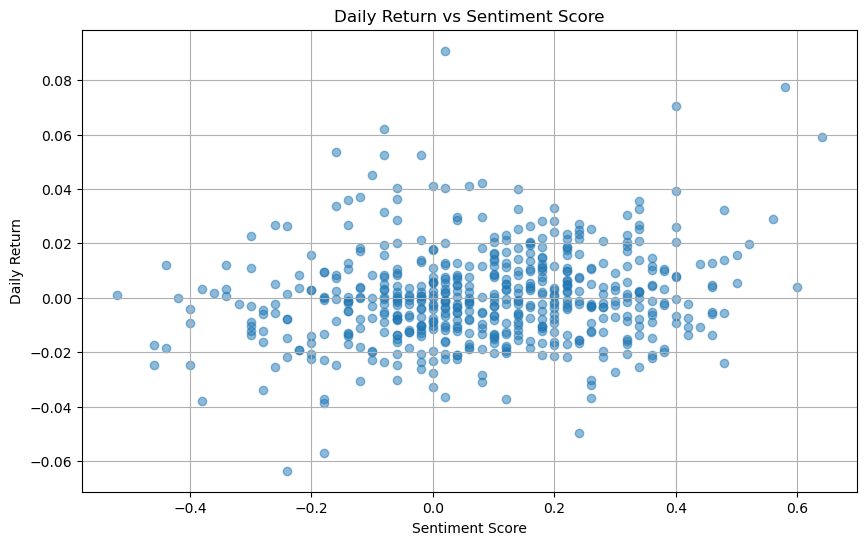

In [34]:
# Scatterplot of Daily Return vs Sentiment
plt.figure(figsize=(10,6))
plt.scatter(df['Sentiment'], df['Daily Return'], alpha=0.5)
plt.title('Daily Return vs Sentiment Score')
plt.xlabel('Sentiment Score')
plt.ylabel('Daily Return')
plt.grid()

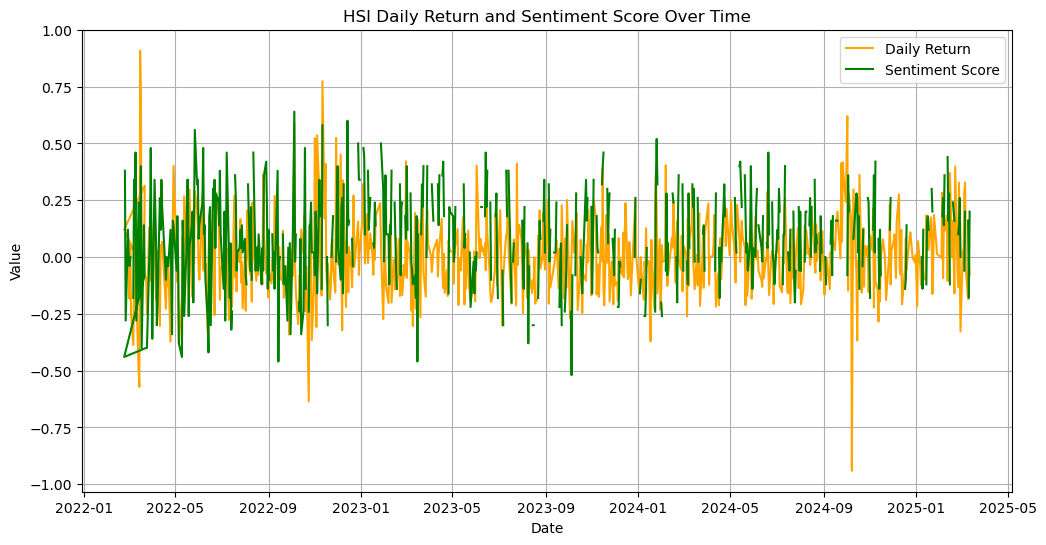

In [35]:
# HSI Returns and Sentiment Values Overlap Line Plot
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Daily Return']*10, label='Daily Return', color='orange')
plt.plot(df['Date'], df['Sentiment'], label='Sentiment Score', color='green')
plt.title('HSI Daily Return and Sentiment Score Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()


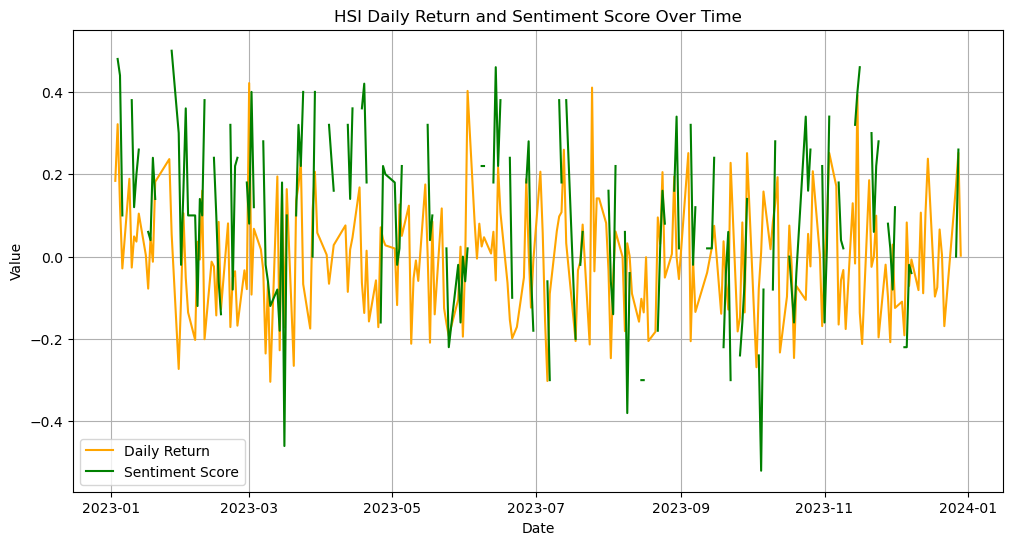

In [36]:
# Reduce Timeframe to 2023
df_2023 = df[df['Date'].dt.year == 2023]
plt.figure(figsize=(12,6))
plt.plot(df_2023['Date'], df_2023['Daily Return']*10, label='Daily Return', color='orange')
plt.plot(df_2023['Date'], df_2023['Sentiment'], label='Sentiment Score', color='green')
plt.title('HSI Daily Return and Sentiment Score Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()


## 4. Correlation Analysis

In [37]:
# Correlation between Daily Return and Sentiment
correlation = df[['Daily Return', 'Sentiment']].corr().iloc[0,1]
print(f"Correlation between Daily Return and Sentiment: {correlation:.4f}")

# Correlation with Lagged Sentiment
df['Sentiment Lagged'] = df['Sentiment'].shift(1)
lagged_correlation = df[['Daily Return', 'Sentiment Lagged']].corr().iloc[0,1]
print(f"Correlation between Daily Return and Lagged Sentiment: {lagged_correlation:.4f}")

Correlation between Daily Return and Sentiment: 0.1683
Correlation between Daily Return and Lagged Sentiment: -0.0630


In [38]:
# Average Sentiment for Every Quartile Returns
df['Return Quartile'] = pd.qcut(df['Daily Return'], 4, labels=False)
avg_sentiment_by_quartile = df.groupby('Return Quartile')['Sentiment'].mean()
print("\nAverage Sentiment by Return Quartile:")
avg_sentiment_by_quartile.round(4)


Average Sentiment by Return Quartile:


Return Quartile
0.0    0.0419
1.0    0.0799
2.0    0.0638
3.0    0.1344
Name: Sentiment, dtype: float64

## 5. Strategy Design

Define strategies using yesterday's Sentiment value to avoid look-ahead bias.

| Strategy | Rule |
|---|---|
| **Buy & Hold** | Always Buy; benchmark |
| **Sentiment Momentum** | Buy if Sentiment > 0, else Short |
| **Threshold (±0.10)** | Buy if > +0.10, Short if < −0.10, else Flat |
| **Contrarian (±0.15)** | Short if > +0.15, Buy if < −0.15, else Flat |


In [39]:
# Generate Signals

# Strategy A - Buy When Sentiment > 0, Sell when < 0
df_bt = df.dropna(subset=['Sentiment Lagged']).copy()  # Backtest dataframe# Strategy A — Sentiment Momentum
df_bt['Sig_A'] = np.where(df_bt['Sentiment Lagged'] > 0, 1, -1)

# Strategy B - Threshold ±0.10
df_bt['Sig_B'] = 0
df_bt.loc[df_bt['Sentiment Lagged'] >  0.10, 'Sig_B'] =  1
df_bt.loc[df_bt['Sentiment Lagged'] < -0.10, 'Sig_B'] = -1

# Strategy C - Contrarian ±0.15
df_bt['Sig_C'] = 0
df_bt.loc[df_bt['Sentiment Lagged'] >  0.15, 'Sig_C'] = -1  # short euphoria
df_bt.loc[df_bt['Sentiment Lagged'] < -0.15, 'Sig_C'] =  1  # long fear

# Strategy returns
df_bt['Ret_BH'] = df_bt['Daily Return']
df_bt['Ret_A']  = df_bt['Sig_A'] * df_bt['Daily Return']
df_bt['Ret_B']  = df_bt['Sig_B'] * df_bt['Daily Return']
df_bt['Ret_C']  = df_bt['Sig_C'] * df_bt['Daily Return']

# Signal distribution for all strategies
print("Signal counts — Strategy A:")
print(df_bt['Sig_A'].value_counts().rename({-1:'Short', 1:'Long'}))
print("\nSignal counts — Strategy B:")
print(df_bt['Sig_B'].value_counts().rename({-1:'Short', 0:'Flat', 1:'Long'}))
print("Signal counts — Contrarian strategy:")
print(df_bt['Sig_C'].value_counts().rename({-1:'Short', 0:'Flat', 1:'Long'}))

Signal counts — Strategy A:
Sig_A
Long     349
Short    202
Name: count, dtype: int64

Signal counts — Strategy B:
Sig_B
Long     272
Flat     177
Short    102
Name: count, dtype: int64
Signal counts — Contrarian strategy:
Sig_C
Flat     274
Short    208
Long      69
Name: count, dtype: int64


## 6. Strategy Testing

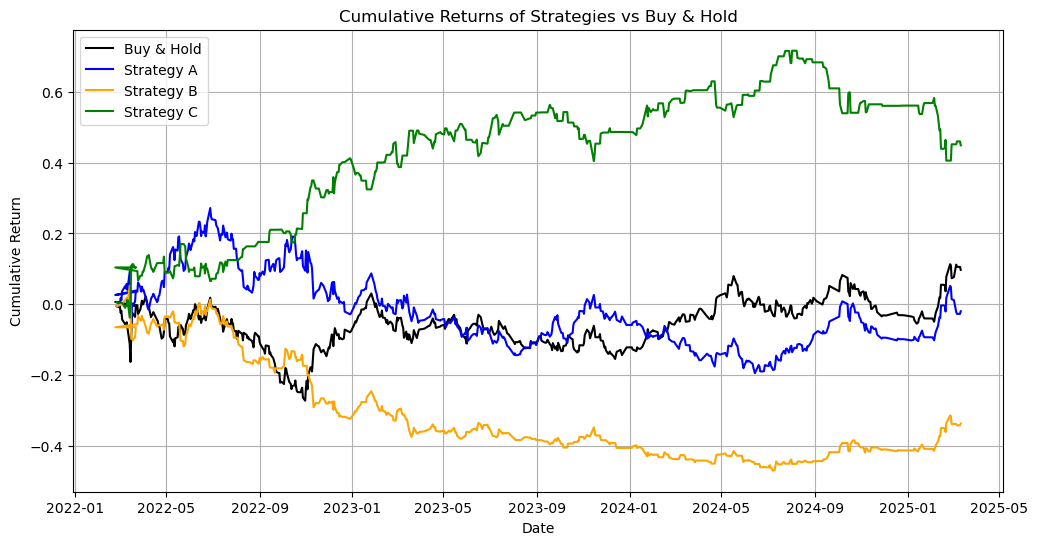

In [40]:
# Testing strategy performance
cumulative_returns = (1 + df_bt[['Ret_BH', 'Ret_A', 'Ret_B', 'Ret_C']]).cumprod() - 1
plt.figure(figsize=(12,6))
plt.plot(df_bt['Date'], cumulative_returns['Ret_BH'], label='Buy & Hold', color='black')
plt.plot(df_bt['Date'], cumulative_returns['Ret_A'], label='Strategy A', color='blue')
plt.plot(df_bt['Date'], cumulative_returns['Ret_B'], label='Strategy B', color='orange')
plt.plot(df_bt['Date'], cumulative_returns['Ret_C'], label='Strategy C', color='green')
plt.title('Cumulative Returns of Strategies vs Buy & Hold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid()

In [43]:
# Compute Total Return, Annualized Return, and Sharpe Ratio for each strategy
results = {}
strategies = ['Ret_BH', 'Ret_A', 'Ret_B', 'Ret_C']
for strat in strategies:
    total_return = cumulative_returns[strat].iloc[-1]
    annualized_return = (1 + total_return) ** (252 / len(df_bt[strat].dropna())) - 1
    sharpe_ratio = (df_bt[strat].mean() / df_bt[strat].std()) * np.sqrt(252)
    results[strat] = {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Sharpe Ratio': sharpe_ratio
    }
results_df = pd.DataFrame(results).T
print("\nStrategy Performance Metrics:")
print(results_df.round(4))



Strategy Performance Metrics:
        Total Return  Annualized Return  Sharpe Ratio
Ret_BH        0.0970             0.0432        0.2907
Ret_A        -0.0201            -0.0093        0.0985
Ret_B        -0.3378            -0.1718       -0.7471
Ret_C         0.4493             0.1850        0.9986


## 7. Conclusion
Among the 4 strategies, the contrarian sentiment strategy where we buy when net sentiments of the previous day is > 0.15 and sell when < -0.15 shows the highest return based on the following back-test results:

| Metric | Buy & Hold | Contrarian (±0.15) |
|---|---|---|
| Total Return | 9.7% | **44.93%** |
| Ann. Return | 4.3% | **18.5** |
| Sharpe Ratio | 0.2907 | **0.9986** |

**Key insights:**
- The lag-1 sentiment correlation is negative (r = −0.063), indicating a mild contrarian signal.
- When the crowd is euphoric (net sentiment > +0.15), the index tends to underperform the next day — and vice versa.

**Limitations to be addressed**
- Missing sentiment data for some of the rows, affecting overall return rate and sentiment analysis due to returns not being independent and identically distributed
- Use of arbitrary threshold for strategy testing (sensitivity analysis)